# Bulk data explorer
This notebook inspects everything under `../data/bulk_downloads` and ties the CSV exports to the files in `downloaded_content`.

The notebook is structured in three passes: (1) summarize every CSV and count how many rows expose downloadable content, (2) scan the filesystem to count downloaded files by type and reconcile them with the CSV expectations, and (3) join the per-file inventory back to an arbitrary CSV via `Document ID`.

In [2]:
from pathlib import Path
import os
import json
import re
import pandas as pd

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable, **kwargs):
        return iterable

BASE_DIR = Path('../data/bulk_downloads').resolve()
DOWNLOAD_DIR_NAME = 'downloaded_content'
print(f'Using base directory: {BASE_DIR}')


Using base directory: /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads


In [4]:
csv_paths = []
for root, dirs, files in os.walk(BASE_DIR):
    dirs[:] = [d for d in dirs if d != DOWNLOAD_DIR_NAME]
    for file_name in files:
        if not file_name.endswith('.csv') or file_name.endswith('_1.csv') or file_name.endswith('_all_text.csv'):
            continue
        csv_paths.append(Path(root) / file_name)
csv_paths = sorted(csv_paths)
print(f'Discovered {len(csv_paths)} CSV exports (skipping *_1 duplicates).')

Discovered 750 CSV exports (skipping *_1 duplicates).


In [6]:
file_df = (
    pd.Series(csv_paths)
         .to_frame('full_path')
         .assign(filename=lambda df: df['full_path'].apply(lambda x: x.name))
)
accepted_filenames = file_df.filename.value_counts().iloc[:4].index.tolist()

In [12]:
sample_df = pd.read_csv(file_df.iloc[3]['full_path'])

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_511/796421627.py:1: DtypeWarning: Columns (50,51,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_df = pd.read_csv(file_df.iloc[3]['full_path'])


In [15]:
sample_df['Attachment Files'].dropna().iloc[1]

'https://downloads.regulations.gov/AMS-CN-16-0108-0004/attachment_1.docx,https://downloads.regulations.gov/AMS-CN-16-0108-0004/attachment_1.pdf'

In [5]:
csv_summary_records = []
# Summarize every CSV and count rows/download links
for csv_path in tqdm(csv_paths, desc='Summarizing CSVs'):
    # Derive agency + collection names from relative path
    rel_parts = csv_path.relative_to(BASE_DIR).parts
    agency = rel_parts[0] if len(rel_parts) > 0 else ''
    collection = rel_parts[1] if len(rel_parts) > 1 else ''
    csv_name = csv_path.stem
    
    # Load CSV as strings so we keep IDs exactly as delivered
    try:
        df = pd.read_csv(csv_path, dtype=str, keep_default_na=False).fillna('')
    except:
        continue 
    for column in ['Content Files', 'Attachment Files']:
        if column not in df.columns:
            df[column] = ''
            
    # Count how many URLs appear in each row
    content_counts = (
        df['Content Files']
            .str.split(',').map(lambda parts: sum(bool(part.strip()) for part in parts))
    )
    attachment_counts = (
        df['Attachment Files']
            .str.split(',').map(lambda parts: sum(bool(part.strip()) for part in parts))
    )
    total_links = content_counts + attachment_counts
    csv_summary_records.append(
        {
            'agency': agency,
            'collection': collection,
            'csv_name': csv_name,
            'csv_path': str(csv_path),
            'rows_total': int(len(df)),
            'rows_with_downloads': int((total_links > 0).sum()),
            'rows_without_downloads': int((total_links == 0).sum()),
            'expected_files': int(total_links.sum()),
            'expected_content_files': int(content_counts.sum()),
            'expected_attachment_files': int(attachment_counts.sum()),
        }
    )
    
csv_summary = (
    pd.DataFrame(csv_summary_records)
    .sort_values(['agency', 'collection', 'csv_name'])
    .reset_index(drop=True)
)
csv_summary.head()

Summarizing CSVs:   0%|          | 0/750 [00:00<?, ?it/s]

,agency,collection,csv_name,csv_path,rows_total,rows_with_downloads,rows_without_downloads,expected_files,expected_content_files,expected_attachment_files
0,agency_list.csv,,agency_list,/Users/spangher/Projects/stanford-research/rfi...,28,0,28,0,0,0
1,ams,ams_2017_2018,notice,/Users/spangher/Projects/stanford-research/rfi...,37,37,0,74,74,0
2,ams,ams_2017_2018,proposed_rule,/Users/spangher/Projects/stanford-research/rfi...,48,48,0,96,96,0
3,ams,ams_2017_2018,public_submission,/Users/spangher/Projects/stanford-research/rfi...,66612,1356,65256,1835,0,1835
4,ams,ams_2017_2018,rule,/Users/spangher/Projects/stanford-research/rfi...,37,37,0,74,74,0


In [6]:
csv_type_totals = (
    csv_summary
    .groupby('csv_name')[['rows_total', 'rows_with_downloads', 'rows_without_downloads', 'expected_files']]
    .sum()
    .sort_values('rows_total', ascending=False)
)
csv_type_totals

,rows_total,rows_with_downloads,rows_without_downloads,expected_files
csv_name,,,,
public_submission,5203710,322823,4880887,488135
notice,54223,54002,221,104940
public_submissions,29357,181,29176,378
rule,12564,12533,31,24632
proposed_rule,10684,10638,46,20124
mapper,1257,0,1257,0
proposed_rules,840,840,0,1340
rules,556,555,1,1086
blank_results,92,0,92,0


## Scan downloaded files

In [39]:
import re

In [16]:
download_records = []

# Inventory every file saved under downloaded_content
agency_dirs = sorted(p for p in BASE_DIR.iterdir() if p.is_dir())
for agency_dir in tqdm(agency_dirs, desc='Scanning agencies'):
    collection_dirs = sorted(p for p in agency_dir.iterdir() if p.is_dir())
    for collection_dir in collection_dirs:
        download_root = collection_dir / DOWNLOAD_DIR_NAME
        if not download_root.is_dir():
            continue
            
        for csv_dir in sorted(p for p in download_root.iterdir() if p.is_dir()):
            source_csv_path = collection_dir / f"{csv_dir.name}.csv"
            for doc_dir in sorted(p for p in csv_dir.iterdir() if p.is_dir()):

                # Each doc directory stores metadata + payloads
                metadata = {}
                metadata_path = doc_dir / 'metadata.json'
                if metadata_path.exists():
                    try:
                        metadata = json.loads(metadata_path.read_text())
                    except json.JSONDecodeError:
                        metadata = {}
                
                # Try to recover the Document ID used in the CSV
                doc_id = None
                for key in ['Document ID', 'DocumentId', 'document_id', 'doc_id', 'DocumentID']:
                    value = metadata.get(key) if isinstance(metadata, dict) else None
                    if value:
                        doc_id = str(value).strip()
                        if doc_id:
                            break
                doc_id = doc_id or doc_dir.name
                
                for file_path in sorted(p for p in doc_dir.iterdir() if p.is_file()):
                    name = file_path.name
                    if name == 'metadata.json':
                        continue
                    if name.endswith('.processing') or name.endswith('.partial') or name.endswith('.stats.json'):
                        continue
                    suffixes = [s.lower() for s in file_path.suffixes]
                    suffix = suffixes[-1] if suffixes else ''
                    is_pdf_text = suffixes[-2:] == ['.pdf', '.txt']
                    kind = 'derived' if is_pdf_text else 'original'
                    page_count = None
                    if is_pdf_text:
                        try:
                            payload = file_path.read_text(encoding='utf-8', errors='ignore')
                        except OSError:
                            payload = ''
                        markers = [int(match.group(1)) for match in re.finditer(r"<<PAGE\s+(\d+)\s*>>", payload)]
                        if markers:
                            page_count = max(markers)

                    download_records.append({
                        'agency': agency_dir.name,
                        'collection': collection_dir.name,
                        'csv_name': csv_dir.name,
                        'source_csv_path': str(source_csv_path),
                        'doc_dir': doc_dir.name,
                        'doc_id': doc_id,
                        'file_name': name,
                        'file_suffix': suffix or '<none>',
                        'file_path': str(file_path),
                        'size_bytes': file_path.stat().st_size,
                        'kind': kind,
                        'page_count': page_count,
                    })
        # break
    # if len(download_records) > 0:
        # break

Scanning agencies:   0%|          | 0/30 [00:00<?, ?it/s]

In [65]:
download_records_df = (
    pd.DataFrame(download_records)
        .assign(file_path_sans_ext=lambda df: df['file_path'].apply(lambda x: Path(x).with_suffix('').with_suffix('')))
)

In [66]:
downloaded_files = (
    download_records_df
         [['file_path_sans_ext', 'file_suffix']]
         .groupby('file_path_sans_ext')['file_suffix']
         .aggregate(list)
)

In [67]:
# downloaded_files.loc[lambda s: s.str.len() == 1].str.get(0)
# downloaded_files.loc[lambda s: s.str.len() == 3]#.loc[lambda s: s.str.get(0) == '.docx']
# ! open /Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/aphis/aphis_2023_2024/downloaded_content/public_submission/APHIS-2020-0030-13244

In [68]:
downloaded_files.str.len().value_counts()

file_suffix
1    377633
2    142403
3        57
4         3
Name: count, dtype: int64

In [81]:
(download_records_df
     .drop_duplicates('file_path_sans_ext')['file_path']
     .apply(lambda x: Path(x).parent).value_counts()
     .head(5)
)

file_path
/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/fws/fws_2017_2018/downloaded_content/public_submission/FWS-R2-ES-2017-0036-9469      1421
/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/epa/epa_2017_2018/downloaded_content/public_submission/EPA-HQ-OAR-2017-0346-0338      710
/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/epa/epa_2017_2018/downloaded_content/public_submission/EPA-HQ-OAR-2010-0505-12318     710
/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/epa/epa_2017_2018/downloaded_content/public_submission/EPA-HQ-OAR-2010-0505-12322     664
/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/epa/epa_2017_2018/downloaded_content/public_submission/EPA-HQ-OAR-2017-0346-0341      664
Name: count, dtype: int64

In [84]:
downloaded_files.loc[lambda s: s.str.len() == 1].str.get(0).value_counts()

file_suffix
.txt     357318
.png       6291
.jpg       6189
.docx      3740
.xlsx      3515
.pptx       160
.htm        114
.pdf         55
.tif         43
.doc         43
.rtf         40
.xlsm        36
.mp4         23
.gif         15
.bmp         13
.wpd         12
.mov         11
.mp3         10
.xls          3
.xlsb         1
.ppt          1
Name: count, dtype: int64

<Axes: xlabel='page_count'>

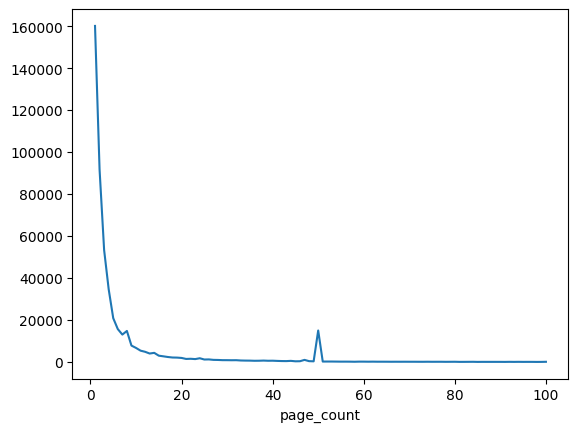

In [57]:
download_records_df['page_count'].value_counts().sort_index().iloc[:100].plot()

In [53]:
downloads_df['kind'].value_counts()

kind
derived     499377
original    163245
Name: count, dtype: int64

In [63]:
download_type_summary = (
    downloads_df
        .groupby('file_suffix')
        .agg(files=('file_name', 'count'), total_size_bytes=('size_bytes', 'sum'))
        .sort_values('files', ascending=False)
)
download_type_summary

,files,total_size_bytes
file_suffix,,
.txt,510897,17144016386
.htm,72928,2256552528
.docx,45442,5765999784
.jpg,20903,19422119396
.png,6806,6854416541
.xlsx,3580,4105701942
.rtf,745,412529577
.pptx,309,1293068615
.doc,289,58709935


In [64]:
original_downloads = downloads_df.loc[lambda d: d['kind'] == 'original'].copy()
expected_total = int(csv_summary['expected_files'].sum())
actual_total = int(original_downloads.shape[0])
print(f'Expected downloads: {expected_total:,}')
print(f'Actual downloads  : {actual_total:,}')

per_csv_downloads = (
    original_downloads
    .groupby(['agency', 'collection', 'csv_name'])
    .size()
    .reset_index(name='actual_files')
)

csv_vs_actual = (
    csv_summary
    .merge(per_csv_downloads, on=['agency', 'collection', 'csv_name'], how='left')
    .fillna({'actual_files': 0})
    .assign(actual_files=lambda df: df['actual_files'].astype(int))
    .assign(missing_files=lambda df: df['expected_files'] - df['actual_files'])
)

csv_vs_actual.head()

Expected downloads: 640,645
Actual downloads  : 163,245


,agency,collection,csv_name,csv_path,rows_total,rows_with_downloads,rows_without_downloads,expected_files,expected_content_files,expected_attachment_files,actual_files,missing_files
0,agency_list.csv,,agency_list,/Users/spangher/Projects/stanford-research/rfi...,28,0,28,0,0,0,0,0
1,ams,ams_2017_2018,notice,/Users/spangher/Projects/stanford-research/rfi...,37,37,0,74,74,0,37,37
2,ams,ams_2017_2018,proposed_rule,/Users/spangher/Projects/stanford-research/rfi...,48,48,0,96,96,0,48,48
3,ams,ams_2017_2018,public_submission,/Users/spangher/Projects/stanford-research/rfi...,66612,1356,65256,1835,0,1835,252,1583
4,ams,ams_2017_2018,rule,/Users/spangher/Projects/stanford-research/rfi...,37,37,0,74,74,0,37,37


In [75]:
pdf_pages = (
    downloads_df
    .drop(columns='page_count').merge(download_records_df[['file_path', 'page_count']])
    .loc[lambda d: d['page_count'].notna()]
)
print(f'PDFs with stats: {len(pdf_pages):,}')
pdf_pages['page_count'].describe(percentiles=[0.5, 0.9, 0.99])

PDFs with stats: 499,335


count    499335.000000
mean         11.403314
std         115.700654
min           1.000000
50%           2.000000
90%          19.000000
99%         100.000000
max       23594.000000
Name: page_count, dtype: float64

## Merge downloads back to a CSV

In [76]:
TARGET = {
    'agency': 'epa',
    'collection': 'epa_2018_2019',
    'csv_name': 'public_submission',
}
# Re-create the source CSV and merge every downloaded file for this docket
target_csv_path = BASE_DIR / TARGET['agency'] / TARGET['collection'] / f"{TARGET['csv_name']}.csv"
if not target_csv_path.exists():
    raise FileNotFoundError(f'Missing CSV {target_csv_path}')

target_df = pd.read_csv(target_csv_path, dtype=str, keep_default_na=False).fillna('')
if 'Document ID' not in target_df.columns and 'DocumentId' in target_df.columns:
    target_df = target_df.rename(columns={'DocumentId': 'Document ID'})

target_df['Document ID'] = target_df['Document ID'].astype(str).str.strip()
target_downloads = downloads_df.loc[
    lambda d: (d['agency'] == TARGET['agency'])
    & (d['collection'] == TARGET['collection'])
    & (d['csv_name'] == TARGET['csv_name'])
]
merged = (
    target_downloads
    .merge(target_df, left_on='doc_id', right_on='Document ID', how='left', suffixes=('_download', '_csv'))
    .sort_values(['doc_id', 'file_name'])
    .reset_index(drop=True)
)
merged[['doc_id', 'file_name', 'file_suffix', 'size_bytes', 'page_count']].head()

,doc_id,file_name,file_suffix,size_bytes,page_count
0,EPA-HQ-OA-2017-0190-63433,attachment_1.pdf.txt,.txt,1573,NaN
1,EPA-HQ-OA-2017-0533-3665,attachment_1.pdf.txt,.txt,1329,NaN
2,EPA-HQ-OA-2017-0533-3666,attachment_1.pdf.txt,.txt,2016,NaN
3,EPA-HQ-OA-2017-0533-3667,attachment_1.pdf.txt,.txt,2087,NaN
4,EPA-HQ-OA-2017-0533-3668,attachment_1.pdf.txt,.txt,1790,NaN


In [77]:
merged_summary = (
    merged
    .groupby(['doc_id', 'file_suffix'])
    .agg(files=('file_name', 'count'), total_bytes=('size_bytes', 'sum'))
    .reset_index()
    .sort_values(['files', 'total_bytes'], ascending=False)
)
merged_summary.head()

,doc_id,file_suffix,files,total_bytes
14307,EPA-HQ-OAR-2018-0283-1132,.txt,31,2703984
14308,EPA-HQ-OAR-2018-0283-1133,.txt,23,1307572
12265,EPA-HQ-OAR-2017-0355-8350,.jpg,20,19173644
13615,EPA-HQ-OAR-2017-0668-0117,.txt,20,2345701
13622,EPA-HQ-OAR-2017-0669-0098,.txt,20,2345701


In [81]:
# Build canonical comment text for the selected CSV (inline + parsed payloads)
comment_columns = [
    col for col in target_df.columns
    if ('comment' in col.lower()) and ('comment on' not in col.lower())
]
print(f'Comment-like columns: {comment_columns or "<none>"}')

inline_series = (
    target_df[comment_columns]
    .fillna('')
    .agg(lambda row: '\n\n'.join([text.strip() for text in row if str(text).strip()]), axis=1)
    if comment_columns else pd.Series('', index=target_df.index)
)
target_with_inline = target_df.assign(inline_text=inline_series)

derived_texts = (
    target_downloads
    .loc[lambda d: d['file_name'].str.endswith('.txt', na=False)]
    .assign(text=lambda df: df['file_path'].apply(lambda p: Path(p).read_text(encoding='utf-8', errors='ignore').strip()))
    .loc[lambda d: d['text'].str.len() > 0]
)
doc_text_map = (
    derived_texts.groupby('doc_id')['text'].apply(list).to_dict()
    if not derived_texts.empty else {}
)

def stitch_comments(row):
    segments = []
    inline = str(row['inline_text']).strip()
    if inline:
        segments.append(inline)
    for extra in doc_text_map.get(row['Document ID'], []):
        cleaned = str(extra).strip()
        if cleaned:
            segments.append(cleaned)
    if not segments:
        return ''
    return '\n\n'.join(
        f"<<COMMENT {idx}>>\n{chunk}"
        for idx, chunk in enumerate(segments, start=1)
    )

canonical_target = target_with_inline.assign(
    canonical_text=lambda df: df.apply(stitch_comments, axis=1)
)
print(
    f"Rows with parsed attachments appended: {canonical_target['canonical_text'].fillna('').str.contains('<<COMMENT 2>>', regex=False).sum():,}"
)
canonical_target[['Document ID', 'canonical_text']].head()

Comment-like columns: ['Comment Start Date', 'Comment Due Date', 'Allow Late Comments', 'Duplicate Comments', 'Comment']
Rows with parsed attachments appended: 21,484


,Document ID,canonical_text
0,EPA-HQ-OA-2008-0701-0013,<<COMMENT 1>>\nfalse\n\n1\n\nISSUE: American h...
1,EPA-HQ-OA-2008-0701-0014,<<COMMENT 1>>\nfalse\n\n1\n\nFocus Groups are ...
2,EPA-HQ-OA-2008-0701-0015,<<COMMENT 1>>\nfalse\n\n1\n\nNot only does Win...
3,EPA-HQ-OA-2008-0701-0016,<<COMMENT 1>>\nfalse\n\n1\n\nTimber sales are ...
4,EPA-HQ-OA-2008-0701-0017,<<COMMENT 1>>\nfalse\n\n1\n\nI know that this ...


In [118]:
# Export canonical text CSVs for the full corpus (inline comment + parsed attachments)
canonical_outputs = []
for csv_path in tqdm(csv_paths, desc='Writing canonical text CSVs'):
    rel_parts = csv_path.relative_to(BASE_DIR).parts
    agency = rel_parts[0] if len(rel_parts) > 0 else ''
    collection = rel_parts[1] if len(rel_parts) > 1 else ''
    csv_name = csv_path.stem
    current_df = pd.read_csv(csv_path, dtype=str, keep_default_na=False).fillna('')
    if 'Document ID' not in current_df.columns and 'DocumentId' in current_df.columns:
        current_df = current_df.rename(columns={'DocumentId': 'Document ID'})
    if 'Document ID' not in current_df.columns:
        print(f'Skipping {csv_path.name} (missing Document ID)')
        continue

    comment_cols = [
        col for col in current_df.columns
        if ('comment' in col.lower()) and ('comment on' not in col.lower())
    ]
    inline_series = (
        current_df[comment_cols]
        .fillna('')
        .agg(lambda row: '\n\n'.join([text.strip() for text in row if str(text).strip()]), axis=1)
        if comment_cols else pd.Series('', index=current_df.index)
    )

    csv_downloads = download_records_df.loc[
        lambda d: (d['agency'] == agency)
        & (d['collection'] == collection)
        & (d['csv_name'] == csv_name)
    ]
    derived_texts = (
        csv_downloads
        .loc[lambda d: d['file_name'].str.endswith('.txt', na=False)]
        .assign(text=lambda df: df['file_path'].apply(
            lambda p: Path(p).read_text(encoding='utf-8', errors='ignore').strip()
            if Path(p).exists() else ''
        ))
        .loc[lambda d: d['text'].str.len() > 0]
    )
    doc_text_map = (
        derived_texts.groupby('doc_id')['text'].apply(list).to_dict()
        if not derived_texts.empty else {}
    )

    def assemble(row):
        pieces = []
        inline_val = str(row['inline_text']).strip()
        if inline_val:
            pieces.append(inline_val)
        for extra in doc_text_map.get(row.get('Document ID', ''), []):
            cleaned = str(extra).strip()
            if cleaned:
                pieces.append(cleaned)
        if not pieces:
            return ''
        return '\n\n'.join(
            f"<<COMMENT {idx}>>\n{chunk}"
            for idx, chunk in enumerate(pieces, start=1)
        )

    enriched = (
        current_df
        .assign(inline_text=inline_series)
        .assign(canonical_text=lambda df: df.apply(assemble, axis=1))
        .drop(columns='inline_text')
    )
    out_path = csv_path.with_name(f"{csv_path.stem}_all_text.csv")
    enriched.to_csv(out_path, index=False)
    canonical_outputs.append({
        'csv_path': str(csv_path),
        'output_path': str(out_path),
        'rows': int(enriched.shape[0]),
        'comment_columns': comment_cols,
        'attachments_used': len(doc_text_map),
    })

canonical_outputs_df = pd.DataFrame(canonical_outputs)
canonical_outputs_df.head()

Writing canonical text CSVs:   0%|          | 0/750 [00:00<?, ?it/s]

Skipping agency_list.csv (missing Document ID)
Skipping blank_results.csv (missing Document ID)
Skipping content_download_errors.csv (missing Document ID)
Skipping supporting_material.csv: Error tokenizing data. C error: Expected 60 fields in line 3057, saw 61

Skipping mapper.csv (missing Document ID)
Skipping public_submission.csv: No columns to parse from file


,csv_path,output_path,rows,comment_columns,attachments_used
0,/Users/spangher/Projects/stanford-research/rfi...,/Users/spangher/Projects/stanford-research/rfi...,37,"[Comment Start Date, Comment Due Date, Allow L...",37
1,/Users/spangher/Projects/stanford-research/rfi...,/Users/spangher/Projects/stanford-research/rfi...,48,"[Comment Start Date, Comment Due Date, Allow L...",48
2,/Users/spangher/Projects/stanford-research/rfi...,/Users/spangher/Projects/stanford-research/rfi...,66612,"[Comment Start Date, Comment Due Date, Allow L...",1345
3,/Users/spangher/Projects/stanford-research/rfi...,/Users/spangher/Projects/stanford-research/rfi...,37,"[Comment Start Date, Comment Due Date, Allow L...",37
4,/Users/spangher/Projects/stanford-research/rfi...,/Users/spangher/Projects/stanford-research/rfi...,18,"[Comment Start Date, Comment Due Date, Allow L...",18


In [138]:
enriched.iloc[0].iloc[0: 30]

Document ID                                              USDA-2021-0012-0001
Agency ID                                                               USDA
Docket ID                                                     USDA-2021-0012
Tracking Number                                                             
Document Type                                                           Rule
Posted Date                                                2023-01-11T05:00Z
Is Withdrawn?                                                          false
Federal Register Number                                           2023-00005
FR Citation                                                                 
Title                      Pandemic Assistance Programs and Agricultural ...
Comment Start Date                                         2023-01-11T05:00Z
Comment Due Date                                        2023-03-14T03:59:59Z
Allow Late Comments                                                    false

In [139]:
enriched.iloc[0].iloc[30 :]

Topics                                       Loan Programs-Agriculture,Natural Resources,Pr...
Duplicate Comments                                                                            
OMB/PRA Approval Number                                                                       
Page Count                                                                                    
Page Length                                                                                   
Paper Width                                                                                   
Special Instructions                                                                          
Source Citation                                                                               
Start End Page                                                                     1862 - 1892
Subject                                                                                       
First Name                                        

In [141]:
out_path

PosixPath('/Users/spangher/Projects/stanford-research/rfi-research/regulations-demo/data/bulk_downloads/usda/usda_2023_2024/rule_all_text.csv')

# Canonical File Names

In [113]:
# print(canonical_target['canonical_text'].loc[lambda s: s.str.contains('<<PAGE 6>>')].iloc[0])

# Agency Hierarchical Mapping

In [2]:
import pandas as pd 

In [1]:
agency_mapping = {
    # HHS agencies
    "nih": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": True},
    "fda": {"head_agency": "HHS", "topic_cluster": "Health & Medical / Food Safety", "collected": True},
    "cdc": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": True},
    "cms": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": True},
    "acf": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": False},
    "hrsa": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": False},
    "samhsa": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": False},
    "acl": {"head_agency": "HHS", "topic_cluster": "Health & Medical", "collected": False},
    
    # USDA agencies
    "usda": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": True},
    "aphis": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": True},
    "ams": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": True},
    "fsis": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": True},
    "fs": {"head_agency": "USDA", "topic_cluster": "Environmental & Natural Resources", "collected": True},
    "nrcs": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": False},
    "rma": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": False},
    "fsa": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": False},
    "rd": {"head_agency": "USDA", "topic_cluster": "Food Safety & Agriculture", "collected": False},
    
    # DHS agencies
    "dhs": {"head_agency": "DHS", "topic_cluster": "Emergency Management & Homeland Security", "collected": True},
    "fema": {"head_agency": "DHS", "topic_cluster": "Emergency Management & Homeland Security", "collected": True},
    "tsa": {"head_agency": "DHS", "topic_cluster": "Transportation Safety / Homeland Security", "collected": True},
    "uscbp": {"head_agency": "DHS", "topic_cluster": "Immigration & Border Security", "collected": True},
    "uscis": {"head_agency": "DHS", "topic_cluster": "Immigration & Border Security", "collected": True},
    "iceb": {"head_agency": "DHS", "topic_cluster": "Immigration & Border Security / Law Enforcement", "collected": True},
    "cisa": {"head_agency": "DHS", "topic_cluster": "Emergency Management & Homeland Security", "collected": False},
    "uscg": {"head_agency": "DHS", "topic_cluster": "Transportation Safety / Homeland Security", "collected": False},
    "usss": {"head_agency": "DHS", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    
    # DOT agencies
    "faa": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": True},
    "nhtsa": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": True},
    "fmcsa": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": False},
    "fra": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": False},
    "fta": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": False},
    "phmsa": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": False},
    "marad": {"head_agency": "DOT", "topic_cluster": "Transportation Safety", "collected": False},
    
    # DOL agencies
    "osha": {"head_agency": "DOL", "topic_cluster": "Worker Safety", "collected": True},
    "msha": {"head_agency": "DOL", "topic_cluster": "Worker Safety", "collected": True},
    "whd": {"head_agency": "DOL", "topic_cluster": "Worker Safety", "collected": False},
    "ebsa": {"head_agency": "DOL", "topic_cluster": "Worker Safety", "collected": False},
    "ofccp": {"head_agency": "DOL", "topic_cluster": "Worker Safety", "collected": False},
    
    # DOC agencies
    "nist": {"head_agency": "DOC", "topic_cluster": "Research & Standards / Communications & Technology", "collected": True},
    "ntia": {"head_agency": "DOC", "topic_cluster": "Communications & Technology", "collected": True},
    "noaa": {"head_agency": "DOC", "topic_cluster": "Environmental & Natural Resources", "collected": False},
    "census": {"head_agency": "DOC", "topic_cluster": "Research & Standards", "collected": False},
    "bis": {"head_agency": "DOC", "topic_cluster": "Financial Regulation", "collected": False},
    "uspto": {"head_agency": "DOC", "topic_cluster": "Research & Standards", "collected": False},
    "eda": {"head_agency": "DOC", "topic_cluster": "Financial Regulation", "collected": False},
    
    # DOJ agencies
    "doj": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": True},
    "fbi": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    "dea": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    "atf": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    "bop": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    "usms": {"head_agency": "DOJ", "topic_cluster": "Law Enforcement & Justice", "collected": False},
    
    # DOE agencies
    "doe": {"head_agency": "DOE", "topic_cluster": "Environmental & Natural Resources / Research & Standards", "collected": True},
    "nnsa": {"head_agency": "DOE", "topic_cluster": "Research & Standards", "collected": False},
    
    # DOI agencies
    "fws": {"head_agency": "DOI", "topic_cluster": "Environmental & Natural Resources", "collected": True},
    "nps": {"head_agency": "DOI", "topic_cluster": "Environmental & Natural Resources", "collected": False},
    "blm": {"head_agency": "DOI", "topic_cluster": "Environmental & Natural Resources", "collected": False},
    "bia": {"head_agency": "DOI", "topic_cluster": "Environmental & Natural Resources", "collected": False},
    "usgs": {"head_agency": "DOI", "topic_cluster": "Research & Standards / Environmental & Natural Resources", "collected": False},
    "boem": {"head_agency": "DOI", "topic_cluster": "Environmental & Natural Resources", "collected": False},
    
    # Independent agencies
    "epa": {"head_agency": "n/a", "topic_cluster": "Environmental & Natural Resources", "collected": True},
    "nsf": {"head_agency": "n/a", "topic_cluster": "Research & Standards", "collected": True},
    "sec": {"head_agency": "n/a", "topic_cluster": "Financial Regulation", "collected": True},
    "fdic": {"head_agency": "n/a", "topic_cluster": "Financial Regulation", "collected": True},
    "fcc": {"head_agency": "n/a", "topic_cluster": "Communications & Technology", "collected": True},
}